In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# XGBoost
from xgboost import XGBClassifier

# Create artifacts directory if it doesn't exist
ARTIFACTS_DIR = "artifacts"
Path(ARTIFACTS_DIR).mkdir(parents=True, exist_ok=True)

In [2]:
# Load Datasets
X_train = pd.read_csv(f"{ARTIFACTS_DIR}/X_train.csv")
X_test = pd.read_csv(f"{ARTIFACTS_DIR}/X_test.csv")
y_train = pd.read_csv(f"{ARTIFACTS_DIR}/y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{ARTIFACTS_DIR}/y_test.csv").squeeze("columns")

# Load existing preprocessor and columns
preprocessor = joblib.load(f"{ARTIFACTS_DIR}/preprocessor.joblib")
feature_columns = joblib.load(f"{ARTIFACTS_DIR}/feature_columns.joblib")

print("Loaded shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Pre-transform the data for XGBoost "epoch" monitoring
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

Loaded shapes: (4000, 14) (1000, 14) (4000,) (1000,)


In [3]:
def train_logistic_regression(preprocessor, X_train, y_train, random_state=42):
    print("--- Training Logistic Regression ---")
    # Setting verbose=1 to show solver iterations (closest thing to epochs for LR)
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=random_state,
        verbose=1 
    )
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

lr_pipeline = train_logistic_regression(preprocessor, X_train, y_train)

--- Training Logistic Regression ---


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [4]:
def train_xgboost_with_epochs(preprocessor, X_train_trans, y_train, X_test_trans, y_test, random_state=42):
    print("\n--- Training XGBoost with Epoch (Boosting Round) Tracking ---")
    
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    scale_pos_weight = (neg / max(pos, 1))

    # Define model with evaluation metric and early stopping
    model = XGBClassifier(
        n_estimators=250,      # This acts as our number of "Epochs"
        max_depth=5,
        learning_rate=0.06,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        early_stopping_rounds=20, # Stops if test loss doesn't improve for 20 epochs
        random_state=random_state,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    )

    # Eval set allows us to watch the training and testing performance per epoch
    eval_set = [(X_train_trans, y_train), (X_test_trans, y_test)]
    
    # Fit the model (verbose=25 prints output every 25 epochs)
    model.fit(
        X_train_trans, y_train, 
        eval_set=eval_set, 
        verbose=25
    )
    
    # Stitch the preprocessor and the newly trained model back into a pipeline for easy deployment
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    return pipe, model

xgb_pipeline, raw_xgb_model = train_xgboost_with_epochs(
    preprocessor, X_train_transformed, y_train, X_test_transformed, y_test
)


--- Training XGBoost with Epoch (Boosting Round) Tracking ---
[0]	validation_0-logloss:0.65087	validation_1-logloss:0.65419
[25]	validation_0-logloss:0.27499	validation_1-logloss:0.33590
[50]	validation_0-logloss:0.20240	validation_1-logloss:0.30377
[75]	validation_0-logloss:0.17636	validation_1-logloss:0.30241
[84]	validation_0-logloss:0.16924	validation_1-logloss:0.30239


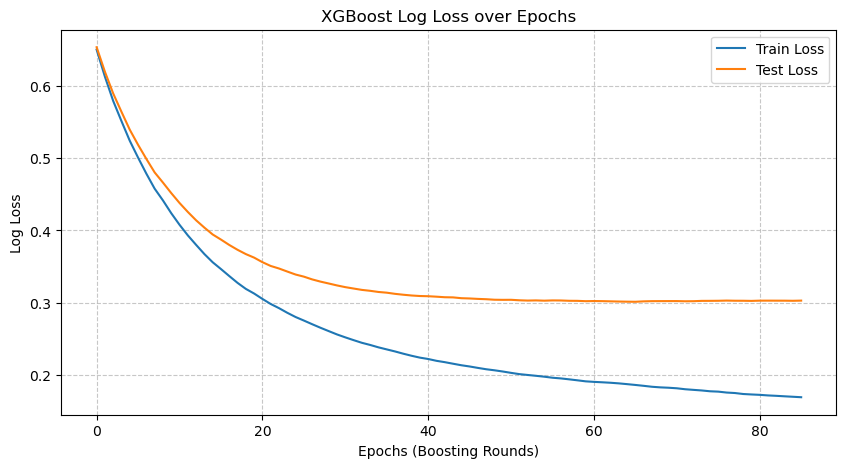

In [5]:
# Extract the evaluation results from the model
results = raw_xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

# Plot Log Loss
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test Loss')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Epochs (Boosting Rounds)')
plt.title('XGBoost Log Loss over Epochs')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [6]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"{name} Classification Report:\n{classification_report(y_test, y_pred, digits=4)}")
    return acc

lr_acc = evaluate_model("Logistic Regression", lr_pipeline, X_test, y_test)
xgb_acc = evaluate_model("XGBoost", xgb_pipeline, X_test, y_test)

print("\n=== Model Comparison ===")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"XGBoost Accuracy:             {xgb_acc:.4f}")
best_model_name = "XGBoost" if xgb_acc >= lr_acc else "Logistic Regression"
print(f"Best model selected: {best_model_name}")


Logistic Regression Accuracy: 0.8730
Logistic Regression Confusion Matrix:
[[704  96]
 [ 31 169]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0     0.9578    0.8800    0.9173       800
           1     0.6377    0.8450    0.7269       200

    accuracy                         0.8730      1000
   macro avg     0.7978    0.8625    0.8221      1000
weighted avg     0.8938    0.8730    0.8792      1000


XGBoost Accuracy: 0.8770
XGBoost Confusion Matrix:
[[714  86]
 [ 37 163]]
XGBoost Classification Report:
              precision    recall  f1-score   support

           0     0.9507    0.8925    0.9207       800
           1     0.6546    0.8150    0.7261       200

    accuracy                         0.8770      1000
   macro avg     0.8027    0.8538    0.8234      1000
weighted avg     0.8915    0.8770    0.8818      1000


=== Model Comparison ===
Logistic Regression Accuracy: 0.8730
XGBoost Accuracy:             0.877

In [7]:
def print_xgb_feature_importance(xgb_pipeline, feature_columns, top_n=20):
    model = xgb_pipeline.named_steps["model"]
    importances = model.feature_importances_
    fi = pd.DataFrame({
        "feature": feature_columns,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\n--- XGBoost Feature Importance ---")
    print(fi.head(top_n).to_string(index=False))

print_xgb_feature_importance(xgb_pipeline, feature_columns)


--- XGBoost Feature Importance ---
                  feature  importance
            crime_density    0.428470
     avg_lighting_quality    0.174014
              hour_of_day    0.068867
            crowd_density    0.053467
crime_type_violence_ratio    0.037100
      street_connectivity    0.032455
          route_length_km    0.031169
              day_of_week    0.029023
        num_intersections    0.028496
       weather_visibility    0.027908
        transit_frequency    0.026838
              crime_trend    0.025248
     transit_lines_nearby    0.023557
               is_holiday    0.013388


In [8]:
def compute_risk_multiplier(probability: float, min_mult: float = 0.7, max_mult: float = 1.3) -> float:
    """Linearly maps probability [0,1] to multiplier range [0.7, 1.3]"""
    return float(min_mult + (max_mult - min_mult) * probability)

def predict_risk(input_features: dict, model_pipeline, feature_columns):
    # Ensure no required features are missing
    missing = [c for c in feature_columns if c not in input_features]
    if missing:
        raise ValueError(f"Missing required features: {missing}")

    # Convert to dataframe
    x = pd.DataFrame([input_features], columns=feature_columns)
    
    # Predict Probability of class 1
    prob = float(model_pipeline.predict_proba(x)[0, 1])
    multiplier = compute_risk_multiplier(prob)
    label = int(prob >= 0.5)

    return {
        "risk_probability": round(prob, 6),
        "risk_multiplier": round(multiplier, 6),
        "risk_label": label
    }

# Assign the best performing pipeline
best_pipeline = xgb_pipeline if xgb_acc >= lr_acc else lr_pipeline

# Example Test Case
sample_input = {
    "crime_density": 0.85,
    "crime_trend": 0.4,
    "crime_type_violence_ratio": 0.7,
    "transit_lines_nearby": 2,
    "transit_frequency": 6,
    "street_connectivity": 0.3,
    "avg_lighting_quality": 25,
    "crowd_density": 15,
    "weather_visibility": 4.5,
    "hour_of_day": 23,
    "day_of_week": 5,
    "is_holiday": 0,
    "route_length_km": 3.2,
    "num_intersections": 8
}

print("Sample Prediction Data:", sample_input)
pred = predict_risk(sample_input, best_pipeline, feature_columns)
print("Prediction Output:", pred)

# Save the final artifacts
joblib.dump(lr_pipeline, f"{ARTIFACTS_DIR}/logistic_regression_pipeline.joblib")
joblib.dump(xgb_pipeline, f"{ARTIFACTS_DIR}/xgboost_pipeline.joblib")
joblib.dump(best_pipeline, f"{ARTIFACTS_DIR}/best_risk_model_pipeline.joblib")

print(f"\nArtifacts successfully saved to /{ARTIFACTS_DIR}!")

Sample Prediction Data: {'crime_density': 0.85, 'crime_trend': 0.4, 'crime_type_violence_ratio': 0.7, 'transit_lines_nearby': 2, 'transit_frequency': 6, 'street_connectivity': 0.3, 'avg_lighting_quality': 25, 'crowd_density': 15, 'weather_visibility': 4.5, 'hour_of_day': 23, 'day_of_week': 5, 'is_holiday': 0, 'route_length_km': 3.2, 'num_intersections': 8}
Prediction Output: {'risk_probability': 0.957328, 'risk_multiplier': 1.274397, 'risk_label': 1}

Artifacts successfully saved to /artifacts!
